In [1]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, davies_bouldin_score, homogeneity_score
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from wordcloud import WordCloud
from sklearn.metrics import silhouette_score

In [2]:
df = pd.read_csv("..\\..\\data\\words\\processed_words_set_from_the_supervisor.csv", encoding='windows-1251')
df

,DocumentName,Word,NormalizedWord,FrequencyInText,FrequencyInCorpus,PartOfSpeech
0,VoenObozren2016_2019_1_0367.t,в,в,85,19397,F
1,VoenObozren2016_2019_1_0366.t,в,в,23,19397,F
2,VoenObozren2016_2019_1_0365.t,в,в,51,19397,F
3,VoenObozren2016_2019_1_0364.t,в,в,59,19397,F
4,VoenObozren2016_2019_1_0363.t,в,в,43,19397,F
...,...,...,...,...,...,...
207078,VoenObozren2016_2019_1_0001.t,калечащих,калечащий,1,1,A
207079,VoenObozren2016_2019_1_0001.t,заточка-пилка,заточка-пилка,1,1,N
207080,VoenObozren2016_2019_1_0001.t,зарослей,заросль,1,1,N
207081,VoenObozren2016_2019_1_0001.t,выручали,выручал,1,1,L


In [3]:
meaningless_pos = {'0', '&', 'F', 'e', 's', 'm', 'M', 'Y', 'n'}
df = df[~df['PartOfSpeech'].isin(meaningless_pos)]
df

,DocumentName,Word,NormalizedWord,FrequencyInText,FrequencyInCorpus,PartOfSpeech
1450,VoenObozren2016_2019_1_0367.t,было,был,13,5324,L
1451,VoenObozren2016_2019_1_0366.t,было,был,5,5324,L
1452,VoenObozren2016_2019_1_0365.t,было,был,30,5324,L
1453,VoenObozren2016_2019_1_0364.t,было,был,4,5324,L
1454,VoenObozren2016_2019_1_0363.t,было,был,19,5324,L
...,...,...,...,...,...,...
207078,VoenObozren2016_2019_1_0001.t,калечащих,калечащий,1,1,A
207079,VoenObozren2016_2019_1_0001.t,заточка-пилка,заточка-пилка,1,1,N
207080,VoenObozren2016_2019_1_0001.t,зарослей,заросль,1,1,N
207081,VoenObozren2016_2019_1_0001.t,выручали,выручал,1,1,L


In [4]:
meaningless_words = {
    'быть', 'был', 'есть', 'будет', 'может', 'мочь', 'являться',
    'имеющий', 'имеющая', 'имеющее', 'имеющие',
    'идущий', 'идущая', 'идущие', 'идущего',
    'он', 'я', 'сам', 'сама', 'само', 'сами', 'тот', 'та', 'то', 'те',
    'такой', 'такая', 'такое', 'такие', 'данный', 'данная', 'данное', 'данные',
    'чего', 'почему', 'зачем', 'где', 'когда', 'пока',
    'уже', 'еще', 'сейчас', 'теперь', 'тогда',
    'должен', 'должна', 'должно', 'должны',
    'человек', 'люди', 'раз', 'мир', 'время', 'год',
    'прошлый', 'следующий', 'новый', 'старый', 'большой', 'маленький',
    'который', 'которая', 'которое', 'которые',
    'поэтому'
}
df = df[~df['NormalizedWord'].isin(meaningless_words)]
df

,DocumentName,Word,NormalizedWord,FrequencyInText,FrequencyInCorpus,PartOfSpeech
5956,VoenObozren2016_2019_1_0364.t,ракеты,ракета,37,2217,N
5957,VoenObozren2016_2019_1_0362.t,ракет,ракета,2,2217,N
5958,VoenObozren2016_2019_1_0359.t,ракет,ракета,1,2217,N
5959,VoenObozren2016_2019_1_0353.t,ракет,ракета,3,2217,N
5960,VoenObozren2016_2019_1_0352.t,ракеты,ракета,1,2217,N
...,...,...,...,...,...,...
207078,VoenObozren2016_2019_1_0001.t,калечащих,калечащий,1,1,A
207079,VoenObozren2016_2019_1_0001.t,заточка-пилка,заточка-пилка,1,1,N
207080,VoenObozren2016_2019_1_0001.t,зарослей,заросль,1,1,N
207081,VoenObozren2016_2019_1_0001.t,выручали,выручал,1,1,L


In [5]:
df = df.copy()
df['FrequencyInText'] = df['FrequencyInText'].astype(int)
df['FrequencyInCorpus'] = df['FrequencyInCorpus'].astype(int)

filtered_df = df[(df['FrequencyInCorpus'] > 1) & (df['FrequencyInText'] > 1)]
doc_word_matrix = filtered_df.pivot_table(
    index='DocumentName',
    columns='NormalizedWord',
    values='FrequencyInText',
    aggfunc='sum',
    fill_value=0
)

filtered_df

,DocumentName,Word,NormalizedWord,FrequencyInText,FrequencyInCorpus,PartOfSpeech
5956,VoenObozren2016_2019_1_0364.t,ракеты,ракета,37,2217,N
5957,VoenObozren2016_2019_1_0362.t,ракет,ракета,2,2217,N
5959,VoenObozren2016_2019_1_0353.t,ракет,ракета,3,2217,N
5962,VoenObozren2016_2019_1_0346.t,ракетами,ракета,2,2217,N
5963,VoenObozren2016_2019_1_0345.t,ракеты,ракета,17,2217,N
...,...,...,...,...,...,...
198152,VoenObozren2016_2019_1_0004.t,плащ-палатка,плащ-палатка,2,2,N
198164,VoenObozren2016_2019_1_0003.t,юнга,юнга,2,2,N
198182,VoenObozren2016_2019_1_0002.t,изготовлять,изготовлять,2,2,I
198187,VoenObozren2016_2019_1_0002.t,Голограммы,голограмма,2,2,N


In [6]:
doc_word_matrix.head(25)

NormalizedWord,Бронеавтомобиль-бронедрезина,Бугско-Днепровско-лиманского,Бугско-Днепровско-лиманскому,абакан,абдалла,абердинский,абонент,абонентский,абрамович,абрамс,...,ярыгин,ясень,ясень-м,ясный,ястреб,яуза,яхонт,ячейка,ящик,яэу
DocumentName,,,,,,,,,,,,,,,,,,,,,
VoenObozren2016_2019_1_0001.t,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
VoenObozren2016_2019_1_0002.t,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
VoenObozren2016_2019_1_0003.t,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
VoenObozren2016_2019_1_0004.t,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
VoenObozren2016_2019_1_0005.t,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
VoenObozren2016_2019_1_0006.t,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
VoenObozren2016_2019_1_0007.t,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
VoenObozren2016_2019_1_0008.t,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
VoenObozren2016_2019_1_0009.t,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [7]:
transformer = TfidfTransformer()
tfidf_matrix = transformer.fit_transform(doc_word_matrix)
similarity_matrix = cosine_similarity(tfidf_matrix)
similarity_df = pd.DataFrame(similarity_matrix, index=doc_word_matrix.index, columns=doc_word_matrix.index)
similarity_df.to_csv("..\\..\\data\\words\\cosine_similarity_matrix.csv", index=True)
similarity_df

DocumentName,VoenObozren2016_2019_1_0001.t,VoenObozren2016_2019_1_0002.t,VoenObozren2016_2019_1_0003.t,VoenObozren2016_2019_1_0004.t,VoenObozren2016_2019_1_0005.t,VoenObozren2016_2019_1_0006.t,VoenObozren2016_2019_1_0007.t,VoenObozren2016_2019_1_0008.t,VoenObozren2016_2019_1_0009.t,VoenObozren2016_2019_1_0010.t,...,VoenObozren2016_2019_1_0358.t,VoenObozren2016_2019_1_0359.t,VoenObozren2016_2019_1_0360.t,VoenObozren2016_2019_1_0361.t,VoenObozren2016_2019_1_0362.t,VoenObozren2016_2019_1_0363.t,VoenObozren2016_2019_1_0364.t,VoenObozren2016_2019_1_0365.t,VoenObozren2016_2019_1_0366.t,VoenObozren2016_2019_1_0367.t
DocumentName,,,,,,,,,,,,,,,,,,,,,
VoenObozren2016_2019_1_0001.t,1.000000,0.000000,0.029114,0.027776,0.019084,0.018251,0.029797,0.004856,0.020811,0.010240,...,0.010750,0.011674,0.038159,0.012233,0.010535,0.004023,0.008339,0.003734,0.000000,0.016480
VoenObozren2016_2019_1_0002.t,0.000000,1.000000,0.002611,0.004589,0.006327,0.013461,0.009964,0.008375,0.008349,0.000000,...,0.026925,0.016808,0.004514,0.004267,0.039640,0.004449,0.025498,0.007069,0.022715,0.007100
VoenObozren2016_2019_1_0003.t,0.029114,0.002611,1.000000,0.007220,0.112791,0.023738,0.014465,0.007801,0.215992,0.006464,...,0.142927,0.226372,0.118115,0.058149,0.031985,0.176767,0.050991,0.001836,0.001759,0.002350
VoenObozren2016_2019_1_0004.t,0.027776,0.004589,0.007220,1.000000,0.087959,0.192849,0.027669,0.012778,0.012292,0.010750,...,0.009011,0.003616,0.030852,0.034803,0.016983,0.008330,0.008291,0.007143,0.009731,0.019675
VoenObozren2016_2019_1_0005.t,0.019084,0.006327,0.112791,0.087959,1.000000,0.097156,0.029512,0.011272,0.078308,0.012718,...,0.058148,0.076393,0.065607,0.044674,0.046763,0.016749,0.024316,0.003691,0.004495,0.012452
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
VoenObozren2016_2019_1_0363.t,0.004023,0.004449,0.176767,0.008330,0.016749,0.011226,0.015826,0.010224,0.029025,0.006174,...,0.023442,0.057068,0.092767,0.049226,0.019148,1.000000,0.054114,0.010309,0.008157,0.011374
VoenObozren2016_2019_1_0364.t,0.008339,0.025498,0.050991,0.008291,0.024316,0.016145,0.018363,0.014691,0.037352,0.015228,...,0.046763,0.034843,0.031096,0.012167,0.058544,0.054114,1.000000,0.006017,0.011159,0.010171
VoenObozren2016_2019_1_0365.t,0.003734,0.007069,0.001836,0.007143,0.003691,0.008569,0.003592,0.003293,0.003600,0.000747,...,0.003781,0.009616,0.008604,0.009132,0.015295,0.010309,0.006017,1.000000,0.535635,0.882336


In [8]:
def save_clusters(labels, method_name):
    cluster_df = pd.DataFrame({"Document": doc_word_matrix.index, "Cluster": labels})
    cluster_df.to_csv(f"..\\..\\data\\words\\{method_name}_clusters.csv", index=False)

def save_cluster_centers(tfidf_matrix, labels, method_name):
    unique_clusters = np.unique(labels)
    cluster_centers = []

    for cluster in unique_clusters:
        if cluster == -1:
            continue
        cluster_indices = np.where(labels == cluster)[0]
        cluster_vectors = tfidf_matrix[cluster_indices].toarray()
        center_idx = np.argmin(cdist([cluster_vectors.mean(axis=0)], cluster_vectors)[0])
        central_file = doc_word_matrix.index[cluster_indices[center_idx]]
        cluster_centers.append((cluster, central_file))

    centers_df = pd.DataFrame(cluster_centers, columns=["Cluster", "Central_File"])
    centers_df.to_csv(f"..\\..\\data\\words\\{method_name}_cluster_centers.csv", index=False)

In [9]:
k = 30
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans_labels = kmeans.fit_predict(tfidf_matrix)
save_clusters(kmeans_labels, "kmeans")
save_cluster_centers(tfidf_matrix, kmeans_labels, "kmeans")

In [10]:
eps = 0.6
min_samples = 5
dbscan = DBSCAN(eps=eps, min_samples=min_samples, metric="cosine")
dbscan_labels = dbscan.fit_predict(tfidf_matrix)
save_clusters(dbscan_labels, "dbscan")
save_cluster_centers(tfidf_matrix, dbscan_labels, "dbscan")

In [11]:
n_clusters_agglo = 35
agglo = AgglomerativeClustering(n_clusters=n_clusters_agglo, metric="cosine", linkage="average")
agglo_labels = agglo.fit_predict(tfidf_matrix.toarray())
save_clusters(agglo_labels, "agglomerative")
save_cluster_centers(tfidf_matrix, agglo_labels, "agglomerative")

In [12]:
def load_clusters(file_name):
    return pd.read_csv(file_name)

In [13]:
kmeans_clusters = load_clusters("..\\..\\data\\words\\kmeans_clusters.csv")
dbscan_clusters = load_clusters("..\\..\\data\\words\\dbscan_clusters.csv")
agglo_clusters = load_clusters("..\\..\\data\\words\\agglomerative_clusters.csv")

kmeans_cluster_centers = load_clusters("..\\..\\data\\words\\kmeans_cluster_centers.csv")
dbscan_cluster_centers = load_clusters("..\\..\\data\\words\\dbscan_cluster_centers.csv")
agglo_cluster_centers = load_clusters("..\\..\\data\\words\\agglomerative_cluster_centers.csv")

In [14]:
def visualize_clusters(labels, tfidf_matrix, method_name):
    tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000, metric='cosine')
    tsne_res = tsne.fit_transform(tfidf_matrix.toarray())

    unique_labels = np.unique(labels)
    cmap = ListedColormap(plt.cm.get_cmap('tab20', len(unique_labels)).colors)

    plt.figure(figsize=(12, 8))
    scatter = plt.scatter(tsne_res[:, 0], tsne_res[:, 1], c=labels, cmap=cmap, s=10, alpha=0.9)
    plt.colorbar(scatter, label=f'{method_name} Cluster', ticks=range(len(unique_labels)))
    plt.title(f't-SNE визуализация кластеров {method_name}')
    plt.xlabel('t-SNE измерение 1')
    plt.ylabel('t-SNE измерение 2')
    plt.grid(True)
    plt.show()

    unique_clusters, counts = np.unique(labels, return_counts=True)
    print(f"{method_name} кластеры:", dict(zip(unique_clusters, counts)))

def generate_word_cloud(cluster_label, cluster_df, method_name):
    cluster_files = cluster_df[cluster_df['Cluster'] == cluster_label]['Document']
    print(f"Файлы в кластере {cluster_label} ({method_name}):")
    for f in cluster_files:
        print(f)

    for doc_name in cluster_files:
        doc_data = filtered_df[filtered_df['DocumentName'] == doc_name]
        word_freq = dict(zip(doc_data['NormalizedWord'], doc_data['FrequencyInText']))
        wc = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word_freq)
        plt.figure(figsize=(10, 5))
        plt.imshow(wc, interpolation='bilinear')
        plt.axis('off')
        plt.title(f'Облако слов для {doc_name}')
        plt.show()

def evaluate_clustering_quality(tfidf_matrix, labels, method_name):
    unique_labels = np.unique(labels)
    
    if len(unique_labels) > 1:
        silhouette = silhouette_score(tfidf_matrix, labels, metric='cosine')
        davies_bouldin = davies_bouldin_score(tfidf_matrix.toarray(), labels)
        homogeneity = homogeneity_score(true_labels, labels) if 'true_labels' in globals() else None
    else:
        silhouette, davies_bouldin, homogeneity = None, None, None
    
    print(f"Метрики качества для {method_name}:")
    print(f"  - Силуэтный коэффициент: {silhouette}")
    print(f"  - Коэффициент Давиеса-Боулдина: {davies_bouldin}")
    if homogeneity is not None:
        print(f"  - Гомогенность: {homogeneity}")

In [15]:
transformer = TfidfTransformer()
tfidf_matrix = transformer.fit_transform(doc_word_matrix)

C:\Users\Juliana\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\manifold\_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
C:\Users\Juliana\AppData\Local\Temp\ipykernel_18524\3451227796.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = ListedColormap(plt.cm.get_cmap('tab20', len(unique_labels)).colors)


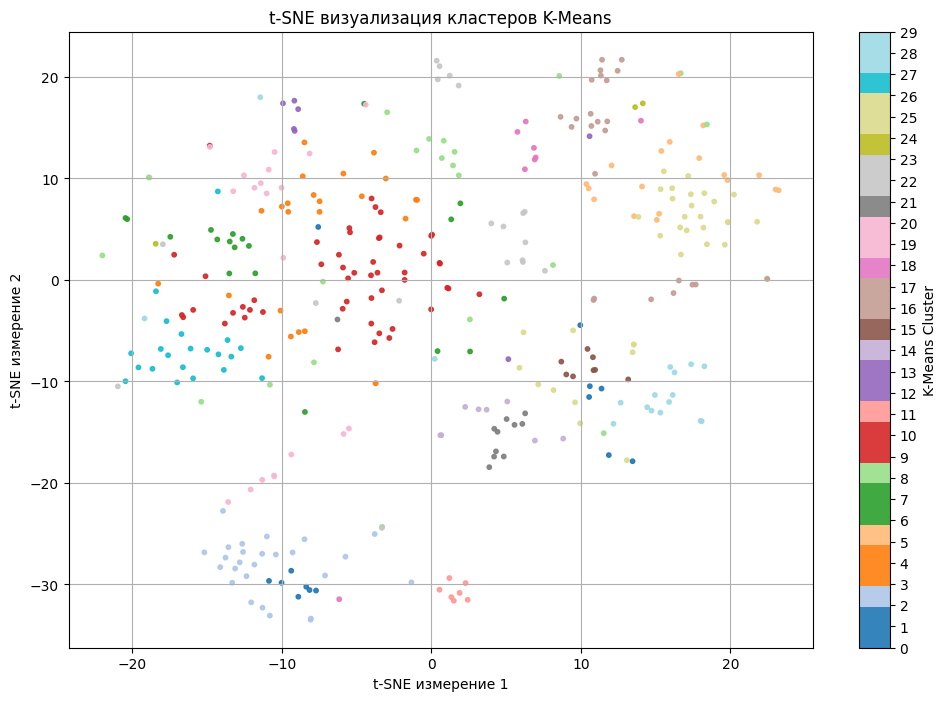

K-Means кластеры: {0: 7, 1: 7, 2: 26, 3: 7, 4: 17, 5: 19, 6: 9, 7: 10, 8: 21, 9: 10, 10: 41, 11: 7, 12: 1, 13: 6, 14: 8, 15: 8, 16: 6, 17: 18, 18: 8, 19: 7, 20: 14, 21: 11, 22: 12, 23: 7, 24: 3, 25: 24, 26: 11, 27: 21, 28: 12, 29: 5}
Файлы в кластере 9 (K-Means):
VoenObozren2016_2019_1_0095.t
VoenObozren2016_2019_1_0097.t
VoenObozren2016_2019_1_0098.t
VoenObozren2016_2019_1_0099.t
VoenObozren2016_2019_1_0101.t
VoenObozren2016_2019_1_0106.t
VoenObozren2016_2019_1_0213.t
VoenObozren2016_2019_1_0214.t
VoenObozren2016_2019_1_0215.t
VoenObozren2016_2019_1_0323.t


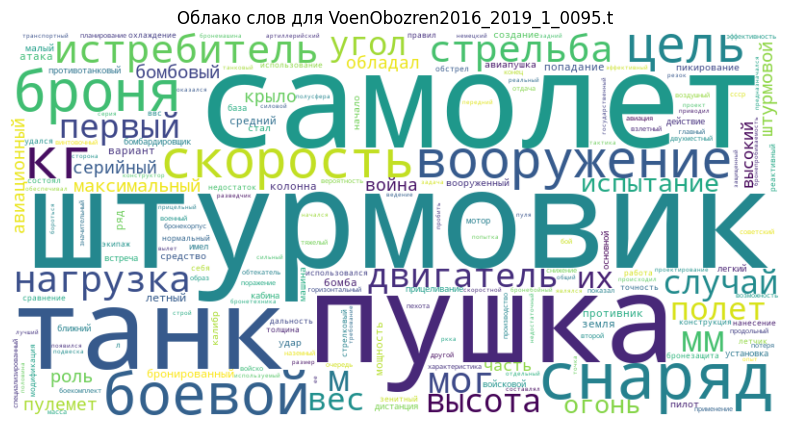

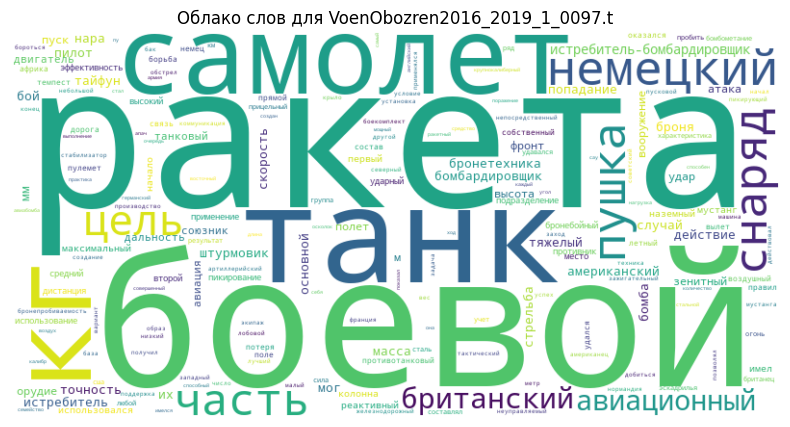

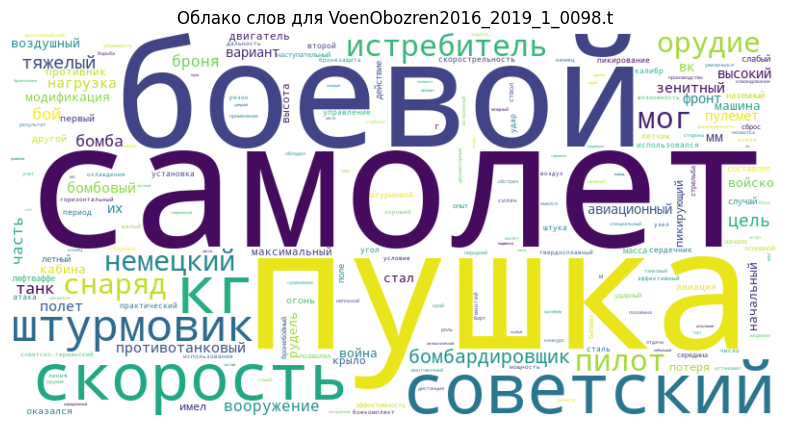

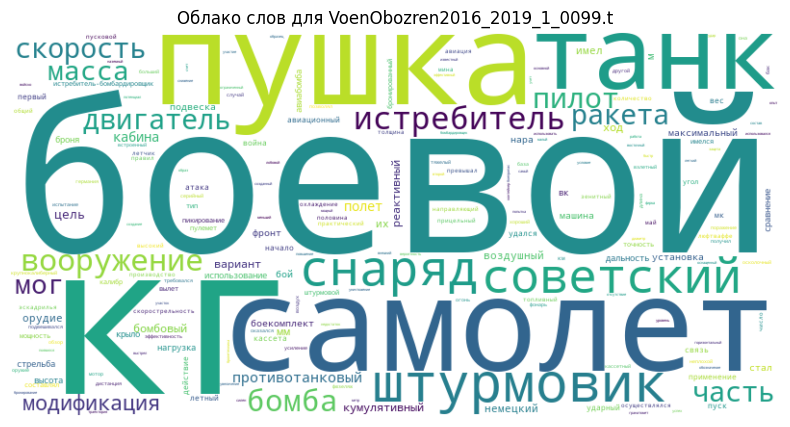

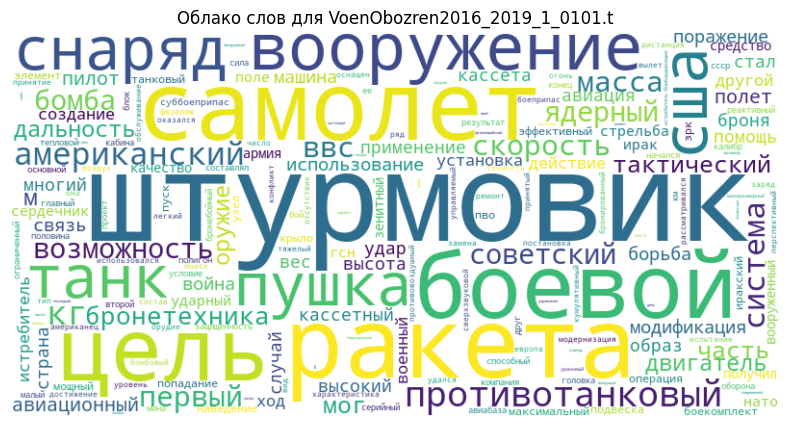

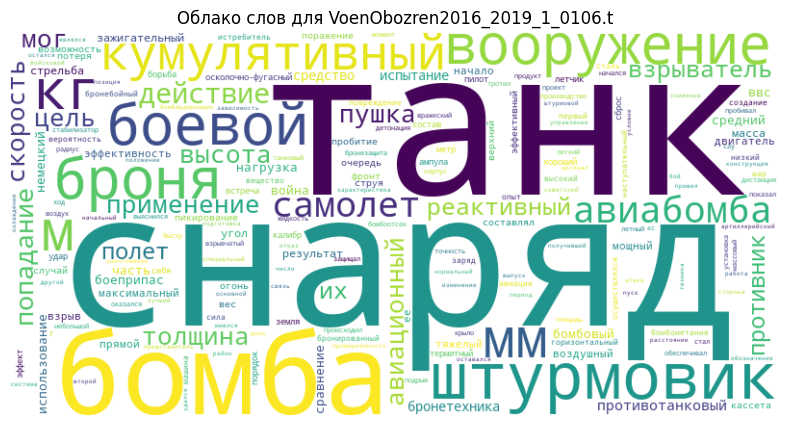

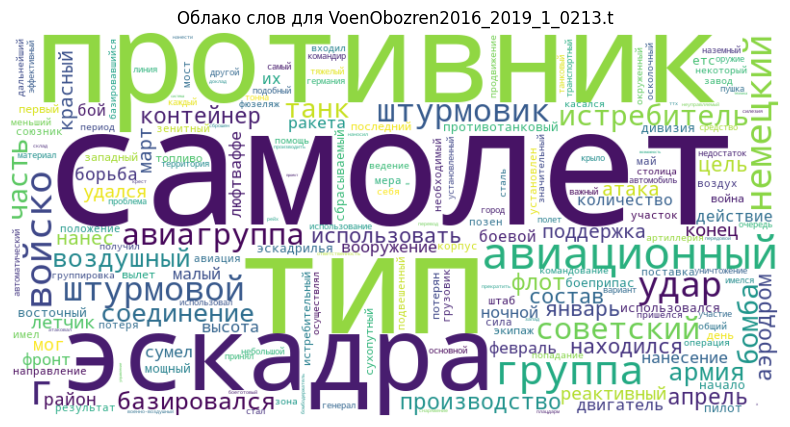

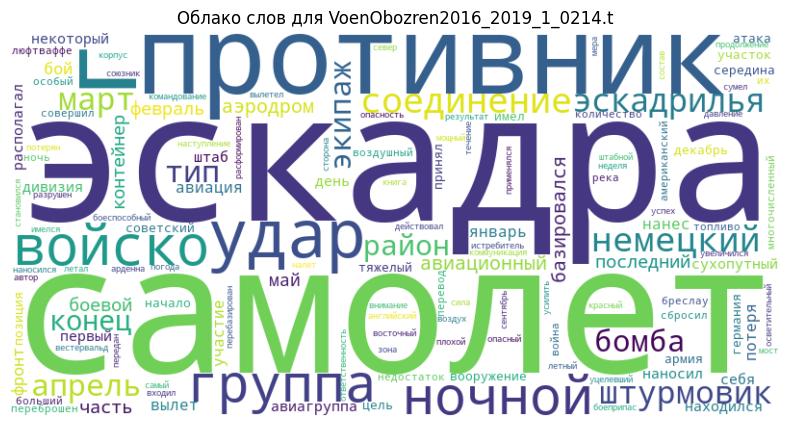

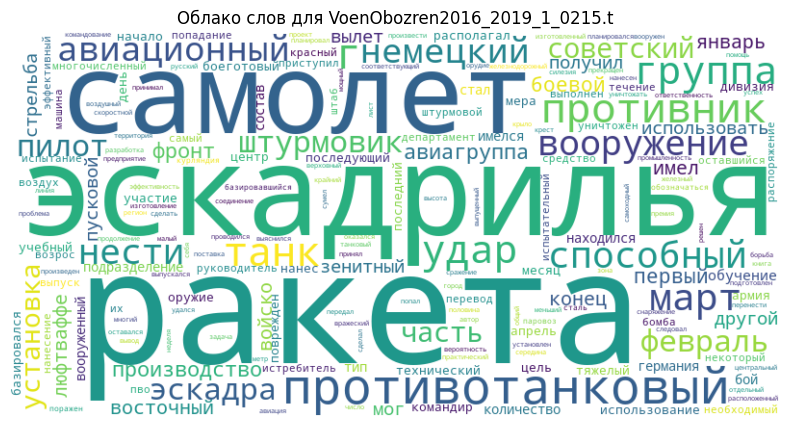

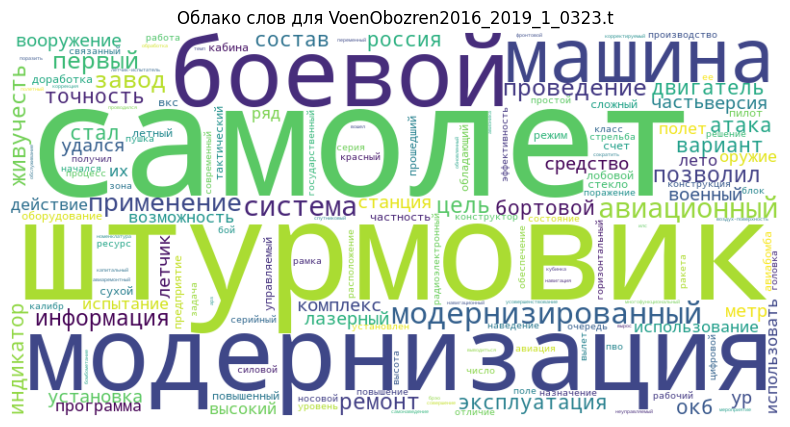

,Document,Cluster
0,VoenObozren2016_2019_1_0001.t,8
1,VoenObozren2016_2019_1_0002.t,22
2,VoenObozren2016_2019_1_0003.t,26
3,VoenObozren2016_2019_1_0004.t,2
4,VoenObozren2016_2019_1_0005.t,27
...,...,...
358,VoenObozren2016_2019_1_0363.t,14
359,VoenObozren2016_2019_1_0364.t,10
360,VoenObozren2016_2019_1_0365.t,11
361,VoenObozren2016_2019_1_0366.t,11


In [16]:
visualize_clusters(kmeans_clusters['Cluster'].values, tfidf_matrix, "K-Means")
generate_word_cloud(9, kmeans_clusters, "K-Means")
kmeans_clusters

In [17]:
kmeans_cluster_centers

,Cluster,Central_File
0,0,VoenObozren2016_2019_1_0337.t
1,1,VoenObozren2016_2019_1_0118.t
2,2,VoenObozren2016_2019_1_0222.t
3,3,VoenObozren2016_2019_1_0077.t
4,4,VoenObozren2016_2019_1_0279.t
5,5,VoenObozren2016_2019_1_0292.t
6,6,VoenObozren2016_2019_1_0105.t
7,7,VoenObozren2016_2019_1_0059.t
8,8,VoenObozren2016_2019_1_0033.t
9,9,VoenObozren2016_2019_1_0099.t


In [19]:
evaluate_clustering_quality(tfidf_matrix, kmeans_labels, "K-Means")

Метрики качества для K-Means:
  - Силуэтный коэффициент: 0.058558126836103265
  - Коэффициент Давиеса-Боулдина: 3.3078590301201967


C:\Users\Juliana\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\manifold\_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
C:\Users\Juliana\AppData\Local\Temp\ipykernel_18524\3451227796.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = ListedColormap(plt.cm.get_cmap('tab20', len(unique_labels)).colors)


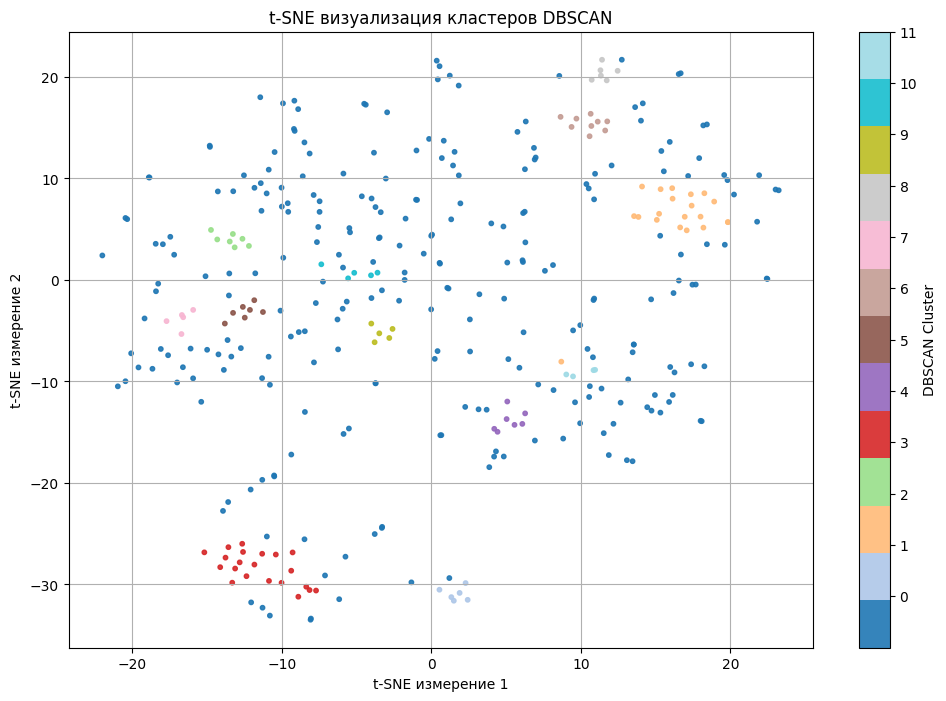

DBSCAN кластеры: {-1: 261, 0: 6, 1: 20, 2: 7, 3: 21, 4: 7, 5: 7, 6: 9, 7: 5, 8: 6, 9: 5, 10: 5, 11: 4}
Файлы в кластере 5 (DBSCAN):
VoenObozren2016_2019_1_0095.t
VoenObozren2016_2019_1_0097.t
VoenObozren2016_2019_1_0098.t
VoenObozren2016_2019_1_0099.t
VoenObozren2016_2019_1_0101.t
VoenObozren2016_2019_1_0106.t
VoenObozren2016_2019_1_0323.t


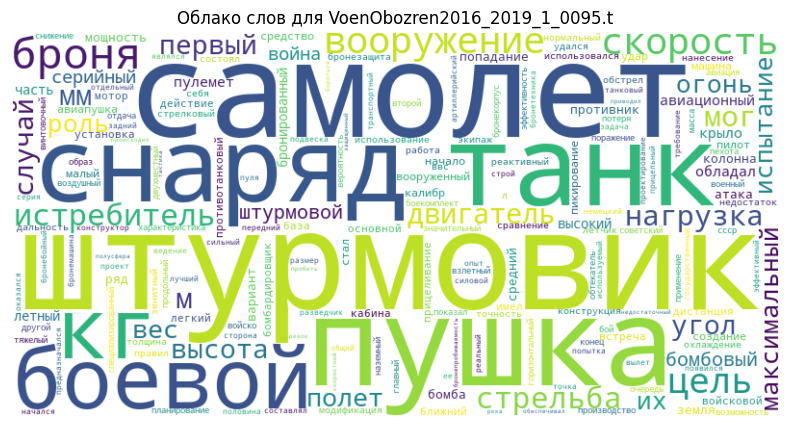

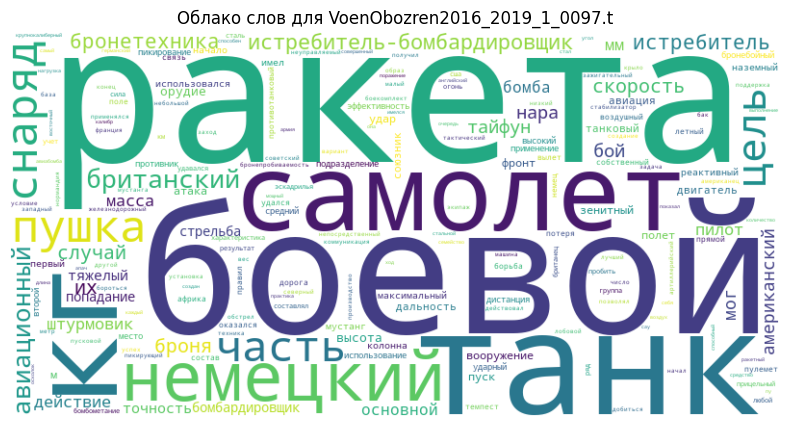

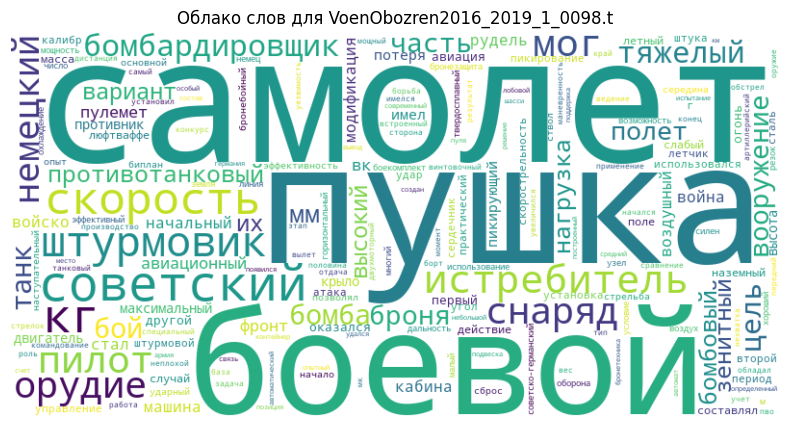

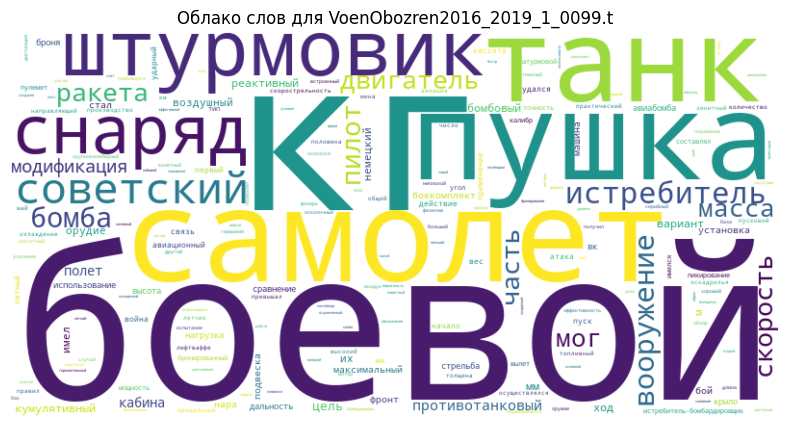

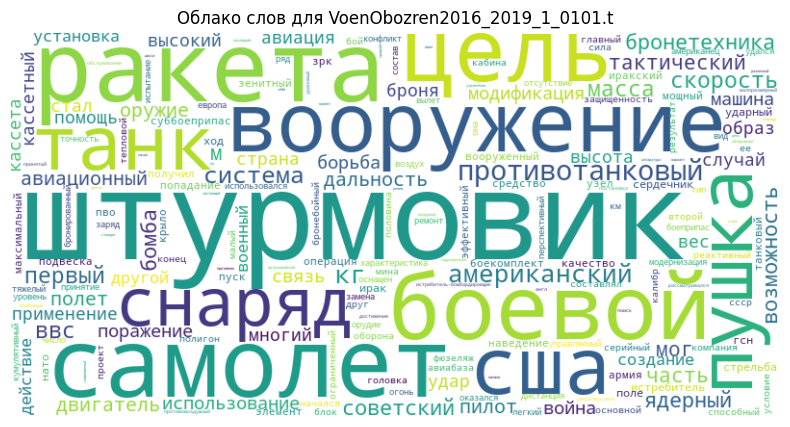

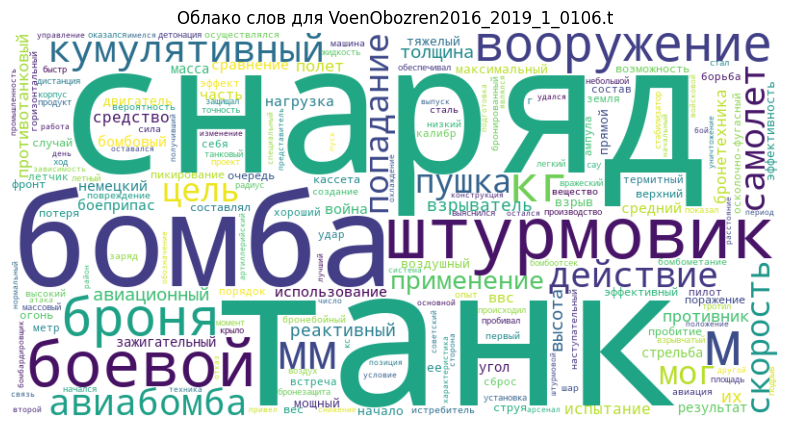

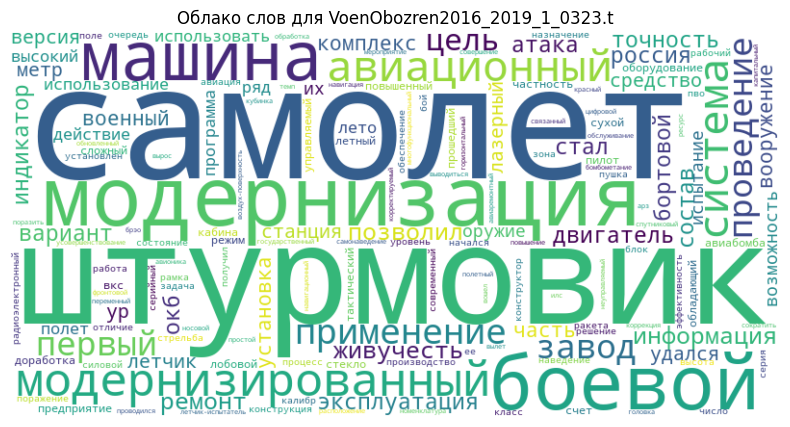

,Document,Cluster
0,VoenObozren2016_2019_1_0001.t,-1
1,VoenObozren2016_2019_1_0002.t,-1
2,VoenObozren2016_2019_1_0003.t,-1
3,VoenObozren2016_2019_1_0004.t,-1
4,VoenObozren2016_2019_1_0005.t,-1
...,...,...
358,VoenObozren2016_2019_1_0363.t,-1
359,VoenObozren2016_2019_1_0364.t,-1
360,VoenObozren2016_2019_1_0365.t,0
361,VoenObozren2016_2019_1_0366.t,0


In [20]:
visualize_clusters(dbscan_clusters['Cluster'].values, tfidf_matrix, "DBSCAN")
generate_word_cloud(5, dbscan_clusters, "DBSCAN")
dbscan_clusters

In [18]:
dbscan_cluster_centers

,Cluster,Central_File
0,0,VoenObozren2016_2019_1_0367.t
1,1,VoenObozren2016_2019_1_0062.t
2,2,VoenObozren2016_2019_1_0105.t
3,3,VoenObozren2016_2019_1_0141.t
4,4,VoenObozren2016_2019_1_0073.t
5,5,VoenObozren2016_2019_1_0095.t
6,6,VoenObozren2016_2019_1_0129.t
7,7,VoenObozren2016_2019_1_0213.t
8,8,VoenObozren2016_2019_1_0248.t
9,9,VoenObozren2016_2019_1_0267.t


In [21]:
evaluate_clustering_quality(tfidf_matrix, dbscan_labels, "DBSCAN")

Метрики качества для DBSCAN:
  - Силуэтный коэффициент: 0.009251633671356146
  - Коэффициент Давиеса-Боулдина: 2.4809148237597145


C:\Users\Juliana\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\manifold\_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
C:\Users\Juliana\AppData\Local\Temp\ipykernel_18524\3451227796.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = ListedColormap(plt.cm.get_cmap('tab20', len(unique_labels)).colors)


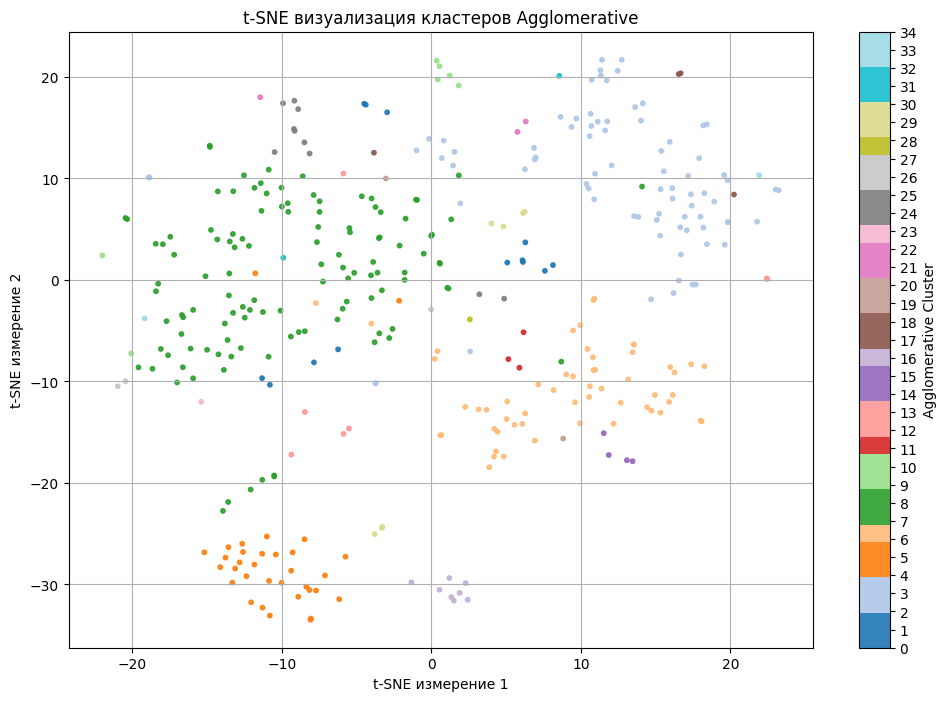

Agglomerative кластеры: {0: 7, 1: 6, 2: 69, 3: 10, 4: 31, 5: 2, 6: 56, 7: 6, 8: 112, 9: 5, 10: 2, 11: 3, 12: 5, 13: 2, 14: 3, 15: 1, 16: 8, 17: 2, 18: 2, 19: 1, 20: 1, 21: 2, 22: 1, 23: 1, 24: 8, 25: 2, 26: 2, 27: 1, 28: 1, 29: 3, 30: 4, 31: 1, 32: 1, 33: 1, 34: 1}
Файлы в кластере 11 (Agglomerative):
VoenObozren2016_2019_1_0009.t
VoenObozren2016_2019_1_0015.t
VoenObozren2016_2019_1_0147.t


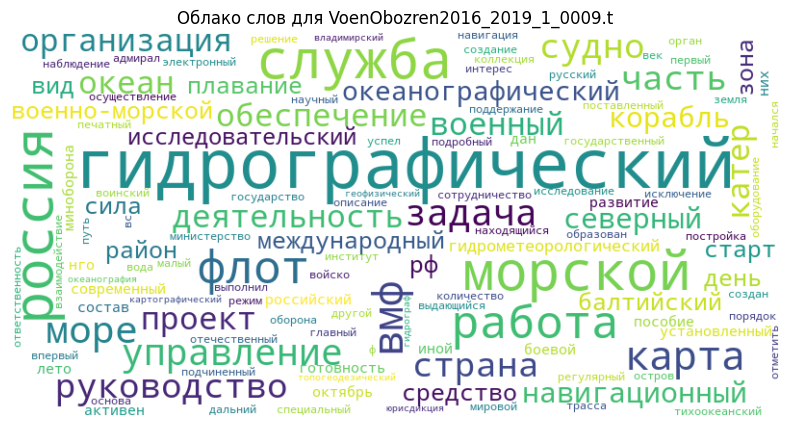

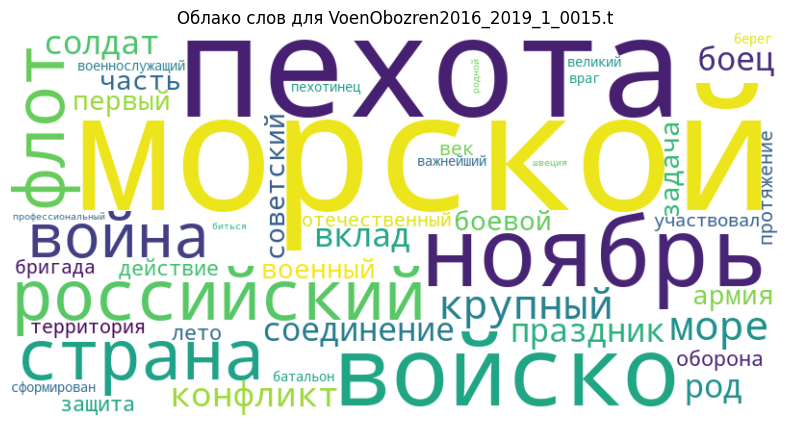

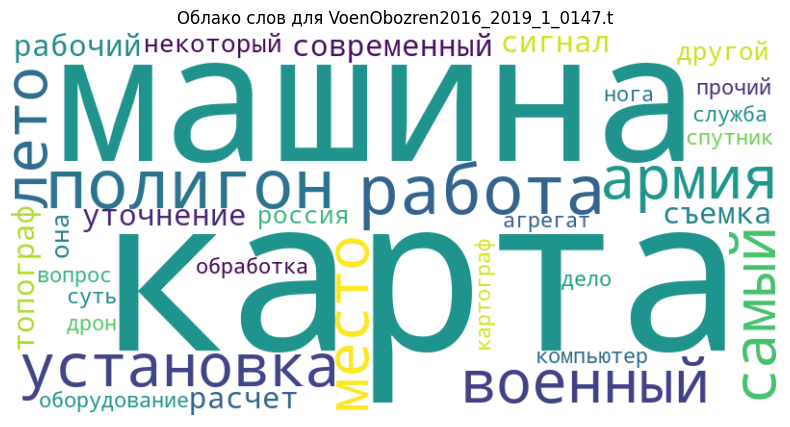

,Document,Cluster
0,VoenObozren2016_2019_1_0001.t,29
1,VoenObozren2016_2019_1_0002.t,30
2,VoenObozren2016_2019_1_0003.t,6
3,VoenObozren2016_2019_1_0004.t,7
4,VoenObozren2016_2019_1_0005.t,8
...,...,...
358,VoenObozren2016_2019_1_0363.t,6
359,VoenObozren2016_2019_1_0364.t,8
360,VoenObozren2016_2019_1_0365.t,16
361,VoenObozren2016_2019_1_0366.t,16


In [22]:
visualize_clusters(agglo_clusters['Cluster'].values, tfidf_matrix, "Agglomerative")
generate_word_cloud(11, agglo_clusters, "Agglomerative")
agglo_clusters

In [23]:
agglo_cluster_centers

,Cluster,Central_File
0,0,VoenObozren2016_2019_1_0020.t
1,1,VoenObozren2016_2019_1_0289.t
2,2,VoenObozren2016_2019_1_0292.t
3,3,VoenObozren2016_2019_1_0033.t
4,4,VoenObozren2016_2019_1_0222.t
5,5,VoenObozren2016_2019_1_0010.t
6,6,VoenObozren2016_2019_1_0073.t
7,7,VoenObozren2016_2019_1_0283.t
8,8,VoenObozren2016_2019_1_0067.t
9,9,VoenObozren2016_2019_1_0342.t


In [24]:
evaluate_clustering_quality(tfidf_matrix, agglo_labels, "Agglomerative")

Метрики качества для Agglomerative:
  - Силуэтный коэффициент: 0.06322258713417464
  - Коэффициент Давиеса-Боулдина: 2.201994011170324


In [25]:
output_path = "..\\..\\data\\words\\dataprocessed_dataset.csv"
df.to_csv(output_path, index=False, encoding='windows-1251')
print(f"Данные успешно сохранены в {output_path}")

Данные успешно сохранены в ..\..\data\words\dataprocessed_dataset.csv
